![logo itq](img/itqlogo.jpeg)

**PROYECTO FINAL - PROCESAMIENTO DE DATASETS**

![logo_python](img/pythonlogo.jpeg)

*Gabriel Culqui*



# INTRODUCCIÓN AL DATA SET

El Registro Estadístico de Entradas y Salidas de ecuatorianos y extranjeros permite cuantificar los movimientos migratorios que se dan durante un periodo de tiempo a través de los diferentes puntos de ingreso y salida del país que existen; incluyen aeropuertos, puertos y cruces terrestres. La información se extiende hasta los propósitos de salida, edad, ocupación, entre otras variables que resultan interesantes para caracterizar la migración en el Ecuador.

El set de datos se encuentra en el siguiente enlace: https://www.ecuadorencifras.gob.ec/entradas-y-salidas-internacionales/

El portal de acceso es la misma página web de Ecuador en Cifras, un proyecto parte del Instituo Nacional de Estadísticas y Censos. La útlima actualización del set fue el año 2024.

# OBJETIVOS DEL PROYECTO

Visibilizar la caracterización de los procesos migratorios en el Ecuador para fundamentar el diseño de políticas públicas orientadas a la gestión fronteriza, la promoción turística y la regulación de la movilidad humana.

Algunos de los usos del presente análisis son:
* Caracterización del flujo migratorio en el Ecuador.
* Determinar los perfiles de las personas que ingresan y salen del país.
* Punto de partida para definición de políticas públicas para atraer más turismo de los perfiles detectados.

# ENFOQUE DEL PROYECTO

El trabajo se orientará a encontrar los siguientes resultados:

* Verificar los meses en los que más movimientos migratorios existen, tanto de entrada como de salida.
* Determinar los puntos migratorios que más movimientos tramitan.
* Analizar las principales causas que motivan los movimientos migratorios en el país.
* Definir el perfil de las personas que ingresan y salen del país por turismo.

El análisis del dataset se basa en un EDA o Exploratory Data Análysis, el cual permite realizar una revisión general del conjunto de datos, encontrar tendencias, caracerizar variables, entre otras. Las herramientas que ofrece esta técnica son varias y muy útiles, todas relacionadas con la estadística descriptiva, desde análisis cuantitativo de variables numéricas hasta gráficas para verificación de tendencias.

# DESCRIPCIÓN TÉCNICA DEL DATASET

El conjunto de datos fue elaborado por el Instituto Nacional de Estadísticas y Censos (INEC). El periodo de estudio es el año 2024. Según el diccionario de variables publicado por la misma entidad, la base cuenta con alrededor de 6.15 millones de observaciones y un total de 25 variables entre cualitativas y cuantitativas. Aborda todos los movimientos de entrada y salida del país desde todos los puntos migratorios autorizados por la autoridad nacional.

# LIBRERÍAS USADAS EN EL TRABAJO

In [1]:
import numpy as np           # Procesa arreglos numéricos y operaciones matemáticas avanzadas
import pandas as pd          # Manipula y analiza datos mediante tablas
import zipfile               # Permite extraer y manipular archivos comprimidos .zip
import urllib.request        # Facilita la descarga de datos y archivos desde url
import os                    # Interactúa con el sistema operativo para gestionar rutas y carpetas
import os.path as osp        # Procesa de forma específica nombres de rutas y extensiones de archivos
import re                    # Aplica expresiones regulares para búsqueda y limpieza de texto
import ssl                   # Maneja certificados de seguridad para conexiones HTTPS seguras
import requests              # Realiza peticiones HTTP para obtener datos de APIs o sitios web
import io                    # Gestiona flujos de datos de entrada/salida en memoria
import matplotlib.pyplot as plt # Genera gráficos estáticos de alta calidad
import plotly.express as px  # Crea visualizaciones e mapas interactivos de forma sencilla

# DESCARGA Y UPLOAD DEL DATASET A LA CARPETA DE TRABAJO

In [2]:
#download dataset 

ruta = osp.join("PF","Datos_abiertos_ ESI_2024.zip")

url = 'https://www.ecuadorencifras.gob.ec/documentos/web-inec/Poblacion_y_Demografia/Migracion/2024/Datos_abiertos_%20ESI_2024.zip'
req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
context = ssl._create_unverified_context()

with urllib.request.urlopen(req, context=context) as response, open(ruta, 'wb') as out_file:
    out_file.write(response.read())
    
#Unzip file
ruta_zip = osp.join("PF", "Datos_abiertos_ ESI_2024.zip")
with zipfile.ZipFile(ruta_zip, 'r') as z1:
    zip_interno = [f for f in z1.namelist() if f.endswith('.zip')][0]
    
    with z1.open(zip_interno) as z2_b:
        z2_data = io.BytesIO(z2_b.read())
        
        with zipfile.ZipFile(z2_data) as z2:
            for member in z2.namelist():
                if "esi_2024" in member.lower() and member.endswith('.csv'):
                    filename = os.path.basename(member)
                    
                    ruta_destino = osp.join("PF", filename)
                    
                    with z2.open(member) as source, open(ruta_destino, 'wb') as target:
                        target.write(source.read())

print(f"Archivo extraído correctamente en: {ruta_destino}")

Archivo extraído correctamente en: PF\esi_2024.csv


# CARGA DEL DATASET AL ENTORNO DE TRABAJO

In [4]:
ruta_csv = osp.join("PF", "esi_2024.csv")

df = pd.read_csv(ruta_csv, sep=',', encoding='utf-8', low_memory=False) 

print(f"Dataset cargado. Filas: {df.shape[0]:,} | Columnas: {df.shape[1]}")
display(df.head())

# Se carga el CSV en un objeto llamado 'df'. Se utiliza la codificación utf-8 
# para asegurar que los nombres de ubicaciones se lean correctamente, 
# y 'low_memory=False' para manejar el gran volumen de datos sin errores. 
# Finalmente, muestra un resumen del tamaño y las primeras filas para verificar la integridad.

Dataset cargado. Filas: 6,153,591 | Columnas: 25


,id_secuencial,tip_movi,tip_naci,anio_movi,mes_movi,dia_movi,sex_migr,nac_migr,subcont_nac,cont_nac,...,lug_prod,pais_res,subcont_res,cont_res,jef_migr,pro_jefm,can_jefm,cla_migr,ocu_migr,edad
0,434783,Salida,Ecuatoriano,2024,Junio,10,Mujer,Ecuador,América del Sur,América,...,Tumbes,Ecuador,América del Sur,América,Centro Binacional de Atención Fronteriza Huaqu...,El Oro,Huaquillas,Clase migratoria para ecuatorianos,Especialistas en politicas de administracion,31
1,2319805,Entrada,Extranjero,2024,Junio,5,Hombre,China,Asia Oriental,Asia,...,Los Ángeles California,China,Asia Oriental,Asia,Aeropuerto Internacional José Joaquín de Olmedo,Guayas,Guayaquil,No inmigrante T-3,Personal de apoyo administrativo no clasificad...,55
2,2705458,Salida,Ecuatoriano,2024,Noviembre,14,Mujer,Ecuador,América del Sur,América,...,Miami Florida,Ecuador,América del Sur,América,Aeropuerto Internacional Mariscal Sucre,Pichincha,Quito,Clase migratoria para ecuatorianos,Sin especificar,38
3,1233217,Salida,Ecuatoriano,2024,Julio,2,Hombre,Ecuador,América del Sur,América,...,Panamá City,Ecuador,América del Sur,América,Aeropuerto Internacional José Joaquín de Olmedo,Guayas,Guayaquil,Clase migratoria para ecuatorianos,Menores de edad,7
4,3063138,Salida,Ecuatoriano,2024,Diciembre,27,Mujer,Ecuador,América del Sur,América,...,Cartagena de Indias,Ecuador,América del Sur,América,Aeropuerto Internacional José Joaquín de Olmedo,Guayas,Guayaquil,Clase migratoria para ecuatorianos,Directores generales y gerentes generales,28


El dataset cargado no se encuentra ordenado de forma secuencial, se podría aplicar un sort para poder verlo de mejor manera

In [5]:
df_ord = df.sort_values(by='id_secuencial', ascending=True).copy()

print(f"Nuevo objeto creado y ordenado. Filas: {len(df_ord):,}")
display(df_ord.head())

# Se genera una copia ordenada por la columna id_secuencial de forma ascendente. Se utiliza '.copy()' 
# para asegurar que sea un objeto independiente en la memoria

Nuevo objeto creado y ordenado. Filas: 6,153,591


,id_secuencial,tip_movi,tip_naci,anio_movi,mes_movi,dia_movi,sex_migr,nac_migr,subcont_nac,cont_nac,...,lug_prod,pais_res,subcont_res,cont_res,jef_migr,pro_jefm,can_jefm,cla_migr,ocu_migr,edad
1172411,1,Salida,Ecuatoriano,2024,Abril,2,Mujer,Ecuador,América del Sur,América,...,Miami Florida,Ecuador,América del Sur,América,Aeropuerto Internacional Eloy Alfaro,Manabí,Manta,Clase migratoria para ecuatorianos,Menores de edad,3
4621515,2,Salida,Extranjero,2024,Julio,1,Mujer,El Salvador,América Central,América,...,San Salvador,El Salvador,América Central,América,Aeropuerto Internacional José Joaquín de Olmedo,Guayas,Guayaquil,No inmigrante T-3,Cuidadores de ninos,38
5109424,3,Salida,Extranjero,2024,Diciembre,21,Mujer,Colombia,América del Sur,América,...,Pasto,Colombia,América del Sur,América,Centro Nacional de Atención Fronteriza Rumichaca,Carchi,Tulcán,No inmigrante T-3,Menores de edad,4
496324,4,Salida,Ecuatoriano,2024,Mayo,24,Mujer,Ecuador,América del Sur,América,...,Lima,Ecuador,América del Sur,América,Aeropuerto Internacional José Joaquín de Olmedo,Guayas,Guayaquil,Clase migratoria para ecuatorianos,Menores de edad,17
5713622,5,Salida,Extranjero,2024,Septiembre,18,Mujer,Venezuela,América del Sur,América,...,Madrid,Venezuela,América del Sur,América,Aeropuerto Internacional Mariscal Sucre,Pichincha,Quito,No inmigrante VT-TUR,Asistentes de venta de tiendas y almacenes,38


Ordenar el dataset no elimina ningun registro, se puede ver como se mantiene el mismo número de observaciones después de aplicar el sort

# LIMPIEZA DEL DATASET
## VERIFICACIÓN DE NAs

Es importante verificar que el dataset esté estructurado y no existan valores perdidos o sin sentido, para ello es necesaria la revisión sistemática en cada una de las variables

In [6]:
tabla_nas = df_ord.isnull().sum().reset_index()
tabla_nas.columns = ['Variable', 'Cantidad de NAs']

display(tabla_nas)

# Calcula la cantidad de valores nulos en cada columna del dataframe. Se usa isnull().sum().
# El print final está filtrado para mostrar únicamente las variables que tienen al menos un valor nulo
# Se usa reset_index para generar la tabla que muestre los valores para cada atributo

,Variable,Cantidad de NAs
0,id_secuencial,0
1,tip_movi,0
2,tip_naci,0
3,anio_movi,0
4,mes_movi,0
5,dia_movi,0
6,sex_migr,0
7,nac_migr,0
8,subcont_nac,0
9,cont_nac,0


La ventaja de usar este dataset es que al ser un registro administrativo esto implica que por lo general se capturan todos los datos en cada observación. Por ello se observa que prácticamente no existen valores perdidos o nulos salvo en la variable "cla_migr" que es clase de migración. Esta es de tipo cualitativa categórica por lo que no se puede imputar con valores, posiblemente se pueda usar la moda para los valores NAs. 

In [18]:
total_registros = len(df_ord)
nulos_cla_migr = df_ord['cla_migr'].isnull().sum()
porcentaje_nulos = (nulos_cla_migr / total_registros) * 100

print(f"Total de registros: {total_registros:,}")
print(f"Nulos en 'cla_migr': {nulos_cla_migr:,}")
print(f"Representan el: {porcentaje_nulos:.2f}% del total") # Se usa .2f para tener solamente 2 decimales

Total de registros: 6,153,591
Nulos en 'cla_migr': 586,046
Representan el: 9.52% del total


En vista de que es un porcentaje realmente alto no se eliminarán los datos, pues esto alteraría de sobremanera las demás variables se procederá a no considerar cla_migr en el análisis exploratorio

## TIPO DE CADA VARIABLE

In [7]:
tabla_tipos = df_ord.dtypes.reset_index()
tabla_tipos.columns = ['Variable', 'Tipo de dato']

num = len(df_ord.select_dtypes(include=[np.number]).columns)
cat = len(df_ord.select_dtypes(exclude=[np.number]).columns)

display(tabla_tipos)

print(f"Variables Numéricas: {num}")
print(f"Variables Categóricas/Texto: {cat}")

,Variable,Tipo de dato
0,id_secuencial,int64
1,tip_movi,object
2,tip_naci,object
3,anio_movi,int64
4,mes_movi,object
5,dia_movi,int64
6,sex_migr,object
7,nac_migr,object
8,subcont_nac,object
9,cont_nac,object


Variables Numéricas: 4
Variables Categóricas/Texto: 21


Existen 21 variables categoricas y 4 numéricas. Sin embargo, al hacer una revisión de la tabla se encuentra que realmente solo hay una cuantitativa 'edad' dado que las otras son el ID, el año y el día, por ende no se puede realmente trabajar con ellas como numéricas

## TABLA DE FRECUENCIAS PARA LAS VARIABLES CATEGÓRICAS
* Obsérvese 'cla_migr', se cuentan también los NAs detectados en apartados anteriores como parte de las categorías de la variable

In [31]:
columns_cat = df_ord.select_dtypes(exclude=['number']).columns

for col in columns_cat:
    print(f"\n***** Análisis de la variable: {col} *****")
    
    tabla = df_ord[col].value_counts(dropna=False).reset_index() # drop.na = False mantiene los NAs, no los ignora en el conteo
    tabla.columns = [col, 'Frecuencia Absoluta']
    tabla['Frecuencia Relativa (%)'] = (tabla['Frecuencia Absoluta'] / len(df_ord)) * 100
    
    display(tabla)

# Se usa for, para generar una tabla de frecuencias relativas y absolutas para cada variable categórica


***** Análisis de la variable: tip_movi *****


,tip_movi,Frecuencia Absoluta,Frecuencia Relativa (%)
0,Salida,3145428,51.115324
1,Entrada,3008163,48.884676



***** Análisis de la variable: tip_naci *****


,tip_naci,Frecuencia Absoluta,Frecuencia Relativa (%)
0,Ecuatoriano,3615141,58.748477
1,Extranjero,2538450,41.251523



***** Análisis de la variable: mes_movi *****


...

,can_jefm,Frecuencia Absoluta,Frecuencia Relativa (%)
0,Quito,2594393,42.160634
1,Guayaquil,2311031,37.555811
2,Huaquillas,648398,10.536904
3,Tulcán,372513,6.053587
4,Manta,71474,1.161501
5,Macará,58970,0.958302
6,Sucumbíos,34463,0.560047
7,Zapotillo,28985,0.471026
8,Chinchipe,13822,0.224617
9,Esmeraldas,4411,0.071682



***** Análisis de la variable: cla_migr *****


,cla_migr,Frecuencia Absoluta,Frecuencia Relativa (%)
0,Clase migratoria para ecuatorianos,3615141,58.748477
1,No inmigrante T-3,1420486,23.083855
2,NaN,586046,9.523642
3,No inmigrante Tripulante,169276,2.750849
4,Inmigrantes 10-VI,57538,0.935031
...,...,...,...
61,No inmigrante 12-VIII,2,0.000033
62,No inmigrante 12-III,2,0.000033
63,InmigranteRP-FAMDIS,2,0.000033
64,No inmigrante RT-CEE,1,0.000016



***** Análisis de la variable: ocu_migr *****


,ocu_migr,Frecuencia Absoluta,Frecuencia Relativa (%)
0,Personal de apoyo administrativo no clasificad...,1444317,23.471124
1,Menores de edad,677901,11.016348
2,Estudiantes,582802,9.470925
3,Amas de casa,438406,7.124393
4,Jubilados y pensionistas,394957,6.418317
...,...,...,...
145,Tecnicos de protesis medicas y dentales,111,0.001804
146,Catadores y clasificadores de alimentos y bebidas,86,0.001398
147,Operadores de maquinas para fabricar productos...,82,0.001333
148,Otros profesores de idiomas,79,0.001284


## DETECCIÓN DE OUTLIERS

Aplicable en la variable cuantitativa 'edad'

In [36]:
q1 = df_ord['edad'].quantile(0.25)
q3 = df_ord['edad'].quantile(0.75)
iqr = q3 - q1 #Rango intercuartílico

limite_inf = q1 - 1.5 * iqr
limite_sup = q3 + 1.5 * iqr

outliers = df_ord[(df_ord['edad'] < limite_inf) | (df_ord['edad'] > limite_sup)]

print(f"Límite inferior para outliers: {limite_inf} (0 años)")
print(f"Límite superior para outliers: {limite_sup}")
print(f"Cantidad de outliers detectados: {len(outliers)}")

display(outliers[['id_secuencial', 'edad', 'mot_viam']].head(10)) #Visualización de outliers desde la cabecera
display(outliers[['id_secuencial', 'edad', 'mot_viam']].tail(10)) #Visualización de outliers desde el final

total_registros = len(df_ord)
q_outliers = len(outliers)
porcentaje_outliers = (q_outliers / total_registros) * 100

print(f"Total de registros en el dataset: {total_registros:}")
print(f"Total de outliers detectados: {q_outliers:}")
print(f"Representación de los outliers: {porcentaje_outliers:.4f}%")

Límite inferior para outliers: -12.0 (0 años)
Límite superior para outliers: 92.0
Cantidad de outliers detectados: 1745


,id_secuencial,edad,mot_viam
5295347,2275,94,Residencia
895058,6810,93,Turismo
1726157,9057,93,Turismo
4752730,17991,93,Residencia
5765663,27574,93,Residencia
2856287,72518,93,Residencia
3417585,72519,93,Residencia
3286382,92118,94,Residencia
3900613,127892,94,Residencia
4313486,127899,95,Residencia


,id_secuencial,edad,mot_viam
207873,6071907,95,Turismo
393318,6071908,94,Turismo
1712398,6071944,95,Turismo
1627324,6071955,93,Turismo
5270815,6077237,93,Residencia
3277898,6084021,94,Residencia
2618781,6113707,93,Residencia
445434,6113724,94,Turismo
219008,6113797,97,Turismo
2284208,6113826,94,Turismo


Total de registros en el dataset: 6153591
Total de outliers detectados: 1745
Representación de los outliers: 0.0284%


En la variable 'edad', la única cuantitativa los outliers representan a penas el 0.0284% de los datos, no es un porcentaje representativo, además observando los datos se puede determinar de que son observaciones válidas se trataría de personas de avanzada edad, si bien se salen del rango y se considerarían valores atípicos no parecen distorcionar el total de la distribución de datos, y sobre todo, no están errados.

## TABLA DE ESTADÍSTICOS DESCRIPTIVOS DE LA VARIABLE CUANTITATIVA

In [39]:
pd.options.display.float_format = '{:.2f}'.format #Configuración para notación normal con dos decimales

resumen_edad = df_ord['edad'].describe().reset_index()
resumen_edad.columns = ['Estadístico', 'Valor']

display(resumen_edad)

,Estadístico,Valor
0,count,6153591.00
1,mean,39.98
2,std,18.30
3,min,0.00
4,25%,27.00
5,50%,39.00
6,75%,53.00
7,max,106.00


Se encuentra que el 50% de las observaciones tiene 39 años o menos, el promedio es muy similar, lo cual indica que en la práctica no existe una asimetría evidente. El flujo migratorio se concentra en adultos y adultos jóvenes lo cual es algo predecible si se habla de migración.

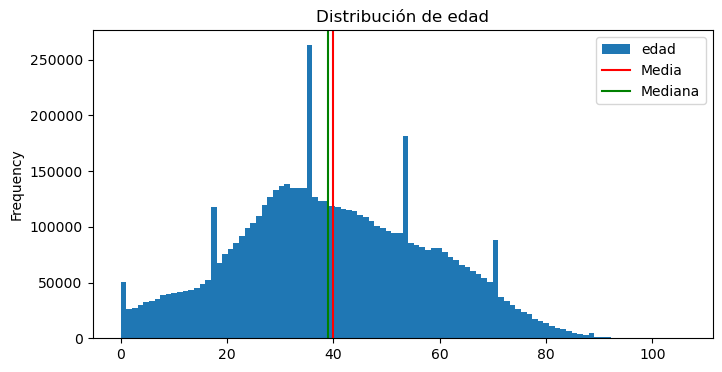

In [8]:
graf1 = df_ord['edad'].plot(kind='hist', bins=100, title='Distribución de edad', figsize=(8,4)) 
graf1.axvline(df_ord['edad'].mean(), color='red', label='Media')
graf1.axvline(df_ord['edad'].median(), color='green', label='Mediana')
graf1.legend()

Se observan varias observaciones con altas frecuencias, pueden indicar puntos de inflexión en momentos cuando los individuos son más propensos a viajar, por ejemplo, 18 años, edad legal para salir del país sin autorización, además de que se abren posibilidades para estudios universitarios. 

Text(0, 0.5, 'Años')

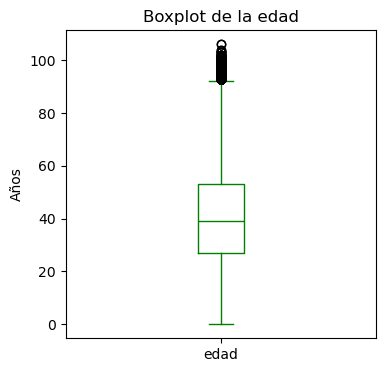

In [11]:
df_ord['edad'].plot(kind='box', vert=True, figsize=(4, 4), color='green')
plt.title('Boxplot de la edad') 
plt.ylabel('Años') 

En el boxplot se logra visualizar los outliers identificados previamente. Se observa cierta regularidad en la distribución de los datos con una acumulación entre el primer y tercer cuartil (edades adultas)

# MESES DE MAYORES MOVIMIENTOS MIGRATORIOS

In [58]:
meses = ['Enero', 'Febrero', 'Marzo', 'Abril', 'Mayo', 'Junio', 'Julio', 'Agosto', 'Septiembre', 'Octubre', 'Noviembre', 'Diciembre']

tabla_cruzada1.index = pd.CategoricalIndex(tabla_cruzada1.index, categories=meses, ordered=True) #Convierte a categórico

tabla_cruzada1 = tabla_cruzada1.sort_index()

total = tabla_cruzada1['Total Mensual'].sum()

tabla_cruzada1['% Relativo'] = (tabla_cruzada1['Total Mensual'] / total) * 100

display(tabla_cruzada1)

tip_movi,Entrada,Salida,Total Mensual,% Relativo
mes_movi,,,,
Enero,215574,243678,459252,7.46
Febrero,208992,249218,458210,7.45
Marzo,243109,285479,528588,8.59
Abril,247836,259205,507041,8.24
Mayo,249519,258214,507733,8.25
Junio,244318,232557,476875,7.75
Julio,273541,285073,558614,9.08
Agosto,310653,326469,637122,10.35
Septiembre,245801,258451,504252,8.19


Se encuentra que el mes con mayor cantidad de movimientos migratorios es Agosto, esto puede deverse a que al ser un periodo de vacaciones en estudios, las personas pueden tender a viajar con sus familias fuera del país, eso se comprueba con el hecho de que hay muchas más salidas que entradas al país. Sucede lo contrario en los meses de noviembre y diciembre cuando se observa mayor cantidad de ingresos lo cual coincide con los periodos de invierno en el hemisferio norte, donde el clima se vuelve mucho más agresivo propendiendo a las personas a viajar a lugares cálidos, entre ellos Ecuador

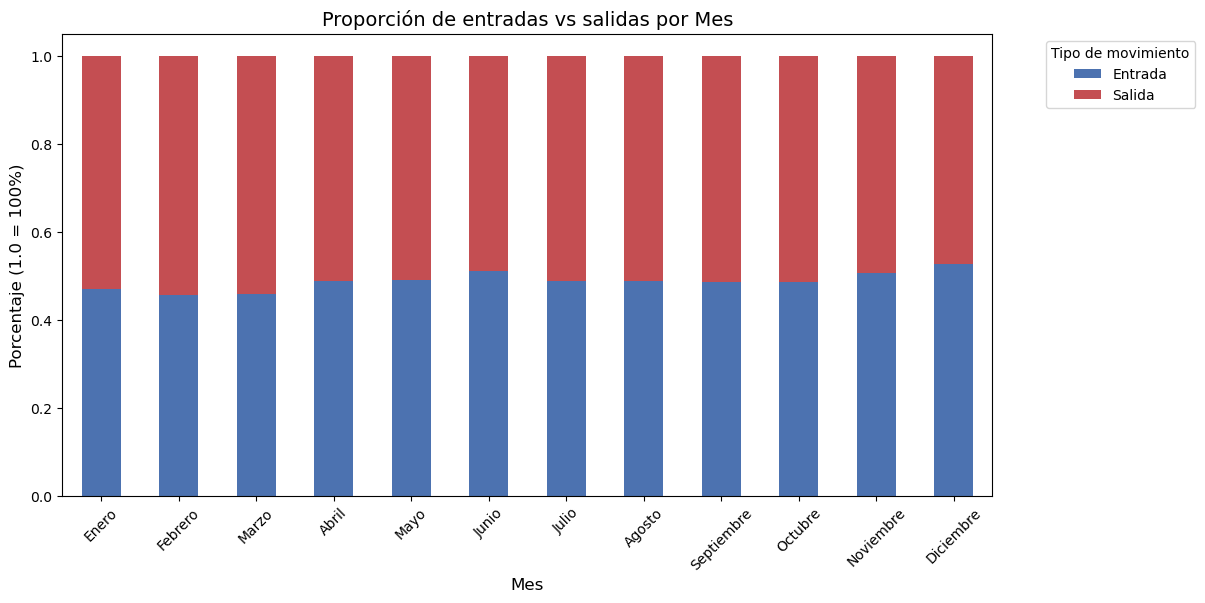

In [61]:
tabla_pct = tabla_cruzada1[['Entrada', 'Salida']].div(tabla_cruzada1['Total Mensual'], axis=0) #Tabla normalizada, total 1
graf2 = tabla_pct.plot(kind='bar', stacked=True, figsize=(12, 6), color=['#4C72B0', '#C44E52'])
for p in graf2.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy() 
    if height > 0:
        ax.text(x + width/2, 
                y + height/2, 
                f'{height*100:.1f}%',
                horizontalalignment='center', 
                verticalalignment='center',
                color='white',
                fontsize=10,
                fontweight='bold')

plt.title('Proporción de entradas vs salidas por Mes', fontsize=14)
plt.xlabel('Mes', fontsize=12)
plt.ylabel('Porcentaje (1.0 = 100%)', fontsize=12)
plt.legend(title='Tipo de movimiento', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)

plt.show()

Las proporciones de entradas y salidas es muy similar en cada mes, casi el 50% en cada una de ellas

# PUNTOS MIGRATORIOS CON MÁS MOVIMIENTOS

In [64]:
tabla_cruzada2 = pd.crosstab(df_ord['jef_migr'], df_ord['tip_movi'])
tabla_cruzada2['Total'] = tabla_cruzada2.sum(axis=1)
tabla_cruzada2 = tabla_cruzada2.sort_values(by='Total', ascending=False)

display(tabla_cruzada2)

tip_movi,Entrada,Salida,Total
jef_migr,,,
Aeropuerto Internacional Mariscal Sucre,1292642,1301751,2594393
Aeropuerto Internacional José Joaquín de Olmedo,1099934,1189063,2288997
Centro Binacional de Atención Fronteriza Huaquillas,309857,338541,648398
Centro Nacional de Atención Fronteriza Rumichaca,180457,191787,372244
Unidad de Control Migratorio Frontera Terrestre Macara,28752,30218,58970
Aeropuerto Internacional Eloy Alfaro,28149,26095,54244
Centro Binacional de Atención Fronteriza San Miguel,17582,16881,34463
Unidad de Control Migratorio Frontera Terrestre Lalamor,14349,14636,28985
Unidad de Control Migratorio Puerto Marítimo Manta,8767,8463,17230


La mayor cantidad de movimientos migratorios se realizan desde los dos aeropuertos internacionales más importantes que tiene el país, tanto Quito como Guayaquil. Esto consolida a esas dos ciudades como las puertas de entrada que el Ecuador tiene para mostrarse al mundo y recibir turistas. Cabe aclarar que, aunque esas dos puntos son los más importantes, la cantidad de movimientos de salida es mayor a la entrada.

Por otro lado, los siguientes tres puntos con mayor movimiento son terrestres, Huaquillas en la frontera sur, Rumichaca en los límites con Colombia y Macará nuevamente en el sur del país.

In [66]:
datos_geo = {
    'jef_migr': [
        'Aeropuerto Internacional Mariscal Sucre', 
        'Aeropuerto Internacional José Joaquín de Olmedo',
        'Centro Binacional de Atención Fronteriza Huaquillas',
        'Centro Nacional de Atención Fronteriza Rumichaca',
        'Unidad de Control Migratorio Frontera Terrestre Macara',
        'Aeropuerto Internacional Eloy Alfaro',
        'Centro Binacional de Atención Fronteriza San Miguel',
        'Unidad de Control Migratorio Frontera Terrestre Lalamor',
        'Unidad de Control Migratorio Puerto Marítimo Manta',
        'Unidad de Control Migratorio Puerto Marítimo Guayaquil'
    ],
    'lat': [-0.1292, -2.1511, -3.4833, 0.8144, -4.3781, -0.9472, 0.1706, -4.3833, -0.9481, -2.2858],
    'long': [-78.3575, -79.8836, -80.2333, -77.6628, -79.9431, -80.6775, -76.8778, -80.4500, -80.7258, -79.9072]
}

df_coords = pd.DataFrame(datos_geo)

tabla_mapa = pd.merge(df_coords, tabla_cruzada2, left_on='jef_migr', right_index=True, how='left')

display(tabla_mapa)

,jef_migr,lat,long,Entrada,Salida,Total
0,Aeropuerto Internacional Mariscal Sucre,-0.13,-78.36,1292642,1301751,2594393
1,Aeropuerto Internacional José Joaquín de Olmedo,-2.15,-79.88,1099934,1189063,2288997
2,Centro Binacional de Atención Fronteriza Huaqu...,-3.48,-80.23,309857,338541,648398
3,Centro Nacional de Atención Fronteriza Rumichaca,0.81,-77.66,180457,191787,372244
4,Unidad de Control Migratorio Frontera Terrestr...,-4.38,-79.94,28752,30218,58970
5,Aeropuerto Internacional Eloy Alfaro,-0.95,-80.68,28149,26095,54244
6,Centro Binacional de Atención Fronteriza San M...,0.17,-76.88,17582,16881,34463
7,Unidad de Control Migratorio Frontera Terrestr...,-4.38,-80.45,14349,14636,28985
8,Unidad de Control Migratorio Puerto Marítimo M...,-0.95,-80.73,8767,8463,17230
9,Unidad de Control Migratorio Puerto Marítimo G...,-2.29,-79.91,7418,8451,15869


C:\Users\Gabriel Alejandro\AppData\Local\Temp\ipykernel_15704\4009468954.py:1: DeprecationWarning:

*scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/



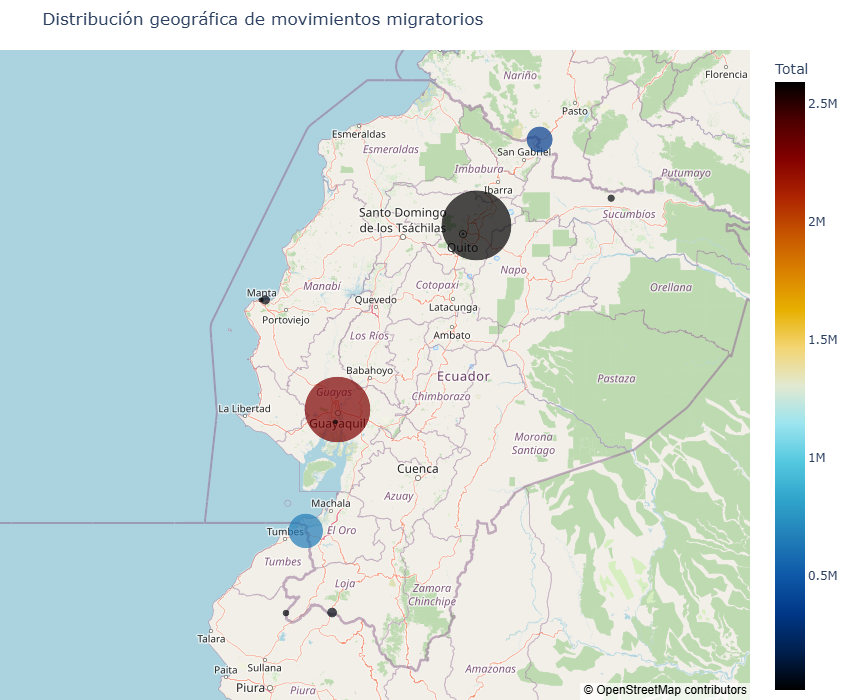

In [71]:
mapa_mig = px.scatter_mapbox(tabla_mapa, 
                        lat="lat", 
                        lon="long", 
                        size="Total", 
                        color="Total",
                        hover_name="jef_migr", 
                        hover_data={"Entrada": True, "Salida": True, "lat": False, "long": False},
                        color_continuous_scale=px.colors.cyclical.IceFire, 
                        size_max=50, 
                        zoom=6,
                        height=700,
                        title='Distribución geográfica de movimientos migratorios')

# Configuramos el estilo del mapa a uno que no requiera Token (OpenStreetMap)
mapa_mig.update_layout(mapbox_style="open-street-map") # Define el fondo del mapa
mapa_mig.update_layout(margin={"r":0,"t":50,"l":0,"b":0}) # Ajusta los márgenes

mapa_mig.show()

La creación de un mapa coroplético es de suma utilidad para comprender la distribución geográfica de los movimientos migratorios en Ecuador durante el 2024

# MOTIVOS DE INGRESO Y SALIDA DE PERSONAS AL PAÍS

In [74]:
#SALIDAS DEL PAÍS

df_salidas = df_ord[df_ord['tip_movi'] == 'Salida']
tabla_mot_sal = pd.crosstab(df_salidas['mot_viam'], df_salidas['tip_movi'])

total_salidas = tabla_mot_sal['Salida'].sum()
tabla_mot_sal['% Relativo'] = (tabla_mot_sal['Salida'] / total_salidas) * 100 

tabla_mot_sal = tabla_mot_sal.sort_values(by='Salida', ascending=False) 

display(tabla_mot_sal)

tip_movi,Salida,% Relativo
mot_viam,,
Turismo,1570768,49.94
Residencia,1245985,39.61
Otros,111912,3.56
Tripulación,82599,2.63
Eventos,67914,2.16
Estudios,35645,1.13
Negocios,28572,0.91
Transeúnte,2033,0.06


In [77]:
#INGRESOS AL PAÍS
df_ingresos = df_ord[df_ord['tip_movi'] == 'Entrada']
tabla_mot_ing = pd.crosstab(df_ingresos['mot_viam'], df_ingresos['tip_movi'])

total_ingresos = tabla_mot_ing['Entrada'].sum()
tabla_mot_ing['% Relativo'] = (tabla_mot_ing['Entrada'] / total_ingresos) * 100 

tabla_mot_ing = tabla_mot_ing.sort_values(by='Entrada', ascending=False) 

display(tabla_mot_ing)

tip_movi,Entrada,% Relativo
mot_viam,,
Residencia,2018926,67.11
Turismo,719219,23.91
Tripulación,84147,2.80
Otros,72698,2.42
Eventos,68116,2.26
Negocios,32153,1.07
Transeúnte,10913,0.36
Estudios,1991,0.07


En el caso salidas del país predominan dos motivos de viaje, Turismo y Residencia; esto indicaría que el 49.97% de las personas que salen del Ecuador regresarían tras su periodo de vacaciones, mientras que el 39.61% no se vive en el país y su salida es permanente. Por otro lado, en el caso de las entradas pasa lo contrario. La mayor cantidad de personas que ingresan se quedan en Ecuador, podría tratarse mayormente de migrantes retornantes. Es interesante observar que existe una mayor cantidad de turismo que se hace hacia fuera del país que del que ingresa, de hecho alrededor de 800 mil casos adicionales representa el turismo que se realiza a nivel internacional. Es un punto de partida para el desarrollo de políticas públicas que conviertan al Ecuador en un destino atractivo para el turismo internacional

# PERFIL DE LAS PERSONAS QUE INGRESAN Y SALEN DEL PAÍS POR TURISMO

In [78]:
df_turismo = df_ord[df_ord['mot_viam'] == 'Turismo'].copy() 
conteo_turismo = len(df_turismo)
display(df_turismo.head()) 
print(f"Se han extraído {conteo_turismo:,} registros con el motivo 'Turismo'.")
#Se crea un nuevo dataframe con los casos seleccionados, solamente con motivo de viaje: Turismo

,id_secuencial,tip_movi,tip_naci,anio_movi,mes_movi,dia_movi,sex_migr,nac_migr,subcont_nac,cont_nac,...,lug_prod,pais_res,subcont_res,cont_res,jef_migr,pro_jefm,can_jefm,cla_migr,ocu_migr,edad
1172411,1,Salida,Ecuatoriano,2024,Abril,2,Mujer,Ecuador,América del Sur,América,...,Miami Florida,Ecuador,América del Sur,América,Aeropuerto Internacional Eloy Alfaro,Manabí,Manta,Clase migratoria para ecuatorianos,Menores de edad,3
496324,4,Salida,Ecuatoriano,2024,Mayo,24,Mujer,Ecuador,América del Sur,América,...,Lima,Ecuador,América del Sur,América,Aeropuerto Internacional José Joaquín de Olmedo,Guayas,Guayaquil,Clase migratoria para ecuatorianos,Menores de edad,17
2283450,27,Salida,Extranjero,2024,Diciembre,31,Mujer,Bolivia,América del Sur,América,...,Miami Florida,Ecuador,América del Sur,América,Aeropuerto Internacional Mariscal Sucre,Pichincha,Quito,Inmigrantes 10-V,Ingenieros en telecomunicaciones,38
1265535,30,Salida,Extranjero,2024,Noviembre,25,Mujer,Irán,Asia Meridional,Asia,...,La Paz,Alemania,Europa Occidental,Europa,Aeropuerto Internacional Mariscal Sucre,Pichincha,Quito,No inmigrante VT-TUR,Personal de apoyo administrativo no clasificad...,31
179121,33,Salida,Extranjero,2024,Julio,4,Mujer,Irán,Asia Meridional,Asia,...,Pereira,Ecuador,América del Sur,América,Aeropuerto Internacional José Joaquín de Olmedo,Guayas,Guayaquil,Inmigrante RP-TEM,Amas de casa,47


Se han extraído 2,289,987 registros con el motivo 'Turismo'.


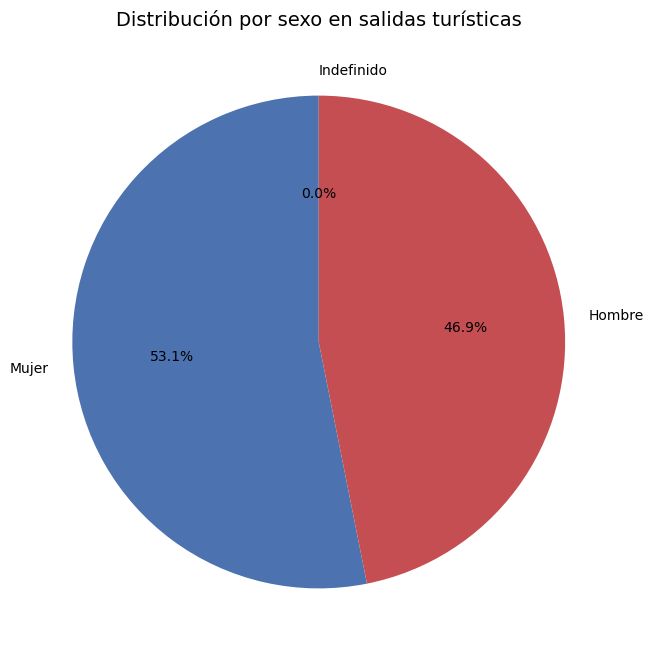

In [85]:
df_turismo_sal = df_turismo[df_turismo['tip_movi'] == 'Salida'].copy()

conteo_sexo = df_turismo_sal['sex_migr'].value_counts() 

plt.figure(figsize=(8, 8)) 
plt.pie(conteo_sexo, 
        labels=conteo_sexo.index, 
        autopct='%1.1f%%', 
        colors=['#4C72B0', '#C44E52', '#8172B3'], #Colores según sexo
        startangle=90) 

plt.title('Distribución por sexo en salidas turísticas', fontsize=14) # Título del reporte
plt.show()

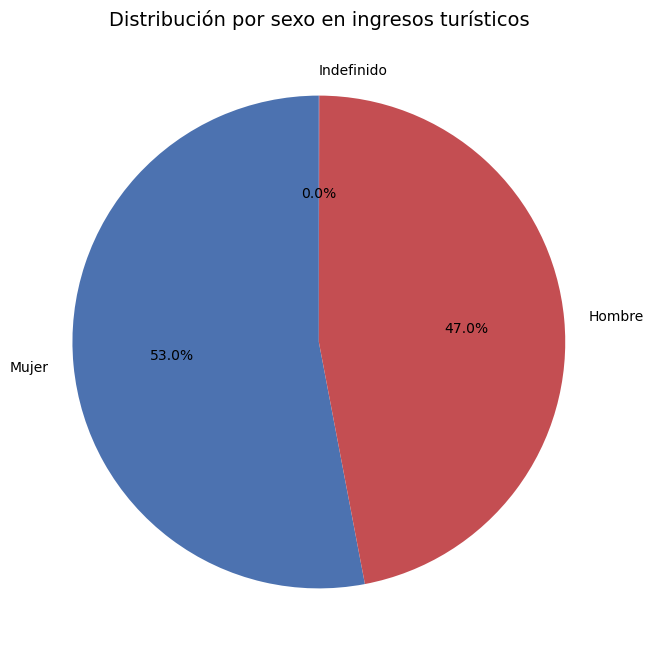

In [87]:
df_turismo_ing = df_turismo[df_turismo['tip_movi'] == 'Entrada'].copy()

conteo_sexo_ing = df_turismo_ing['sex_migr'].value_counts() 

plt.figure(figsize=(8, 8)) 
plt.pie(conteo_sexo_ing, 
        labels=conteo_sexo.index, 
        autopct='%1.1f%%', 
        colors=['#4C72B0', '#C44E52', '#8172B3'], #Colores según sexo
        startangle=90) 

plt.title('Distribución por sexo en ingresos turísticos', fontsize=14) # Título del reporte
plt.show()

La distribución por sexo es prácticamente identica en entradas y salidas en cuanto a sexo. Se observa más movimiento en mujeres, aproximadamente 6% puntos porcentuales por encima a los hombres.

In [92]:
pd.options.display.float_format = '{:.2f}'.format #Configuración para notación normal con dos decimales

resumen_edad_sal = df_turismo_sal['edad'].describe().reset_index()
resumen_edad_sal.columns = ['Estadístico', 'Valor']

display(resumen_edad_sal)

print("-"*50)

resumen_edad_ing = df_turismo_ing['edad'].describe().reset_index()
resumen_edad_ing.columns = ['Estadístico', 'Valor']

display(resumen_edad_ing)


,Estadístico,Valor
0,count,1570768.00
1,mean,38.40
2,std,18.62
3,min,0.00
4,25%,26.00
5,50%,37.00
6,75%,51.00
7,max,106.00


--------------------------------------------------


,Estadístico,Valor
0,count,719219.00
1,mean,39.32
2,std,19.10
3,min,0.00
4,25%,25.00
5,50%,38.00
6,75%,54.00
7,max,102.00


La edad de las personas que salen del país es en promedio 38 años. Mientras que los que ingresan están alrededor de los 39 años. Existe una ligera tendencia a que las personas que entran a Ecuador por turismo son ligeramente mayores, aunque la diferencia probablemente no es significativa.

In [94]:
pais_freq_sal_abs = df_turismo_sal['pais_prod'].value_counts()
pais_freq_sal_rel = df_turismo_sal['pais_prod'].value_counts(normalize=True) * 100

tab_pais_sal = pd.DataFrame({
    'Frecuencia Absoluta': pais_freq_sal_abs,
    'Frecuencia Relativa (%)': pais_freq_sal_rel})

display(tab_pais_sal)

,Frecuencia Absoluta,Frecuencia Relativa (%)
pais_prod,,
Estados Unidos de América,464750,29.59
Colombia,304232,19.37
Perú,299320,19.06
Panamá,70359,4.48
El Salvador,67955,4.33
...,...,...
Mauritania,1,0.00
Malaui,1,0.00
Gabón,1,0.00


Casi el 30% de las personas viaja a Estados Unidos, seguido en segundo lugar por Colombia y luego Perú. Es decir se quedan en el mismo continente

In [95]:
pais_freq_ing_abs = df_turismo_ing['pais_prod'].value_counts()
pais_freq_ing_rel = df_turismo_ing['pais_prod'].value_counts(normalize=True) * 100

tab_pais_ing = pd.DataFrame({
    'Frecuencia Absoluta': pais_freq_ing_abs,
    'Frecuencia Relativa (%)': pais_freq_ing_rel})

display(tab_pais_ing)

,Frecuencia Absoluta,Frecuencia Relativa (%)
pais_prod,,
Estados Unidos de América,228504,31.77
Colombia,178214,24.78
Perú,102025,14.19
España,43458,6.04
Panamá,17158,2.39
...,...,...
Suazilandia,1,0.00
Cabo Verde,1,0.00
Togo,1,0.00


En el caso de los turistas que ingresan a Ecuador la tendencia se repite provienen de Estados Unidos, Colombia o Perú mayormente

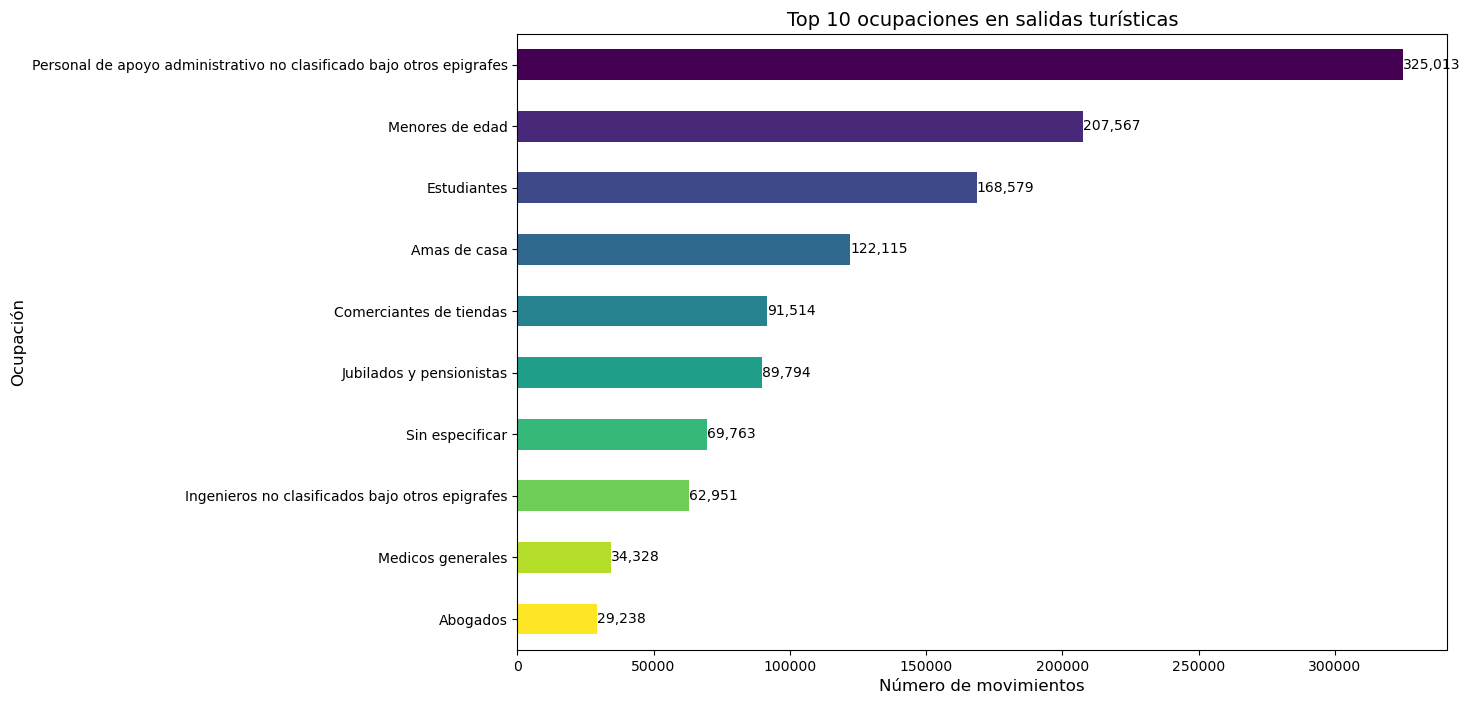

In [110]:
freq_ocup_sal = df_turismo_sal['ocu_migr'].value_counts().head(10)

top_ocup_sal = freq_ocup_sal.plot(kind='barh', figsize=(12, 8), color=plt.get_cmap('viridis')
                                  (np.linspace(0, 1, len(freq_ocup_ing))))

plt.title('Top 10 ocupaciones en salidas turísticas', fontsize=14)
plt.xlabel('Número de movimientos', fontsize=12)
plt.ylabel('Ocupación', fontsize=12)
plt.gca().invert_yaxis()

for i, v in enumerate(freq_ocup_sal):
    top_ocup_sal.text(v + 3, i, f'{int(v):,}', va='center', fontsize=10)

plt.show()

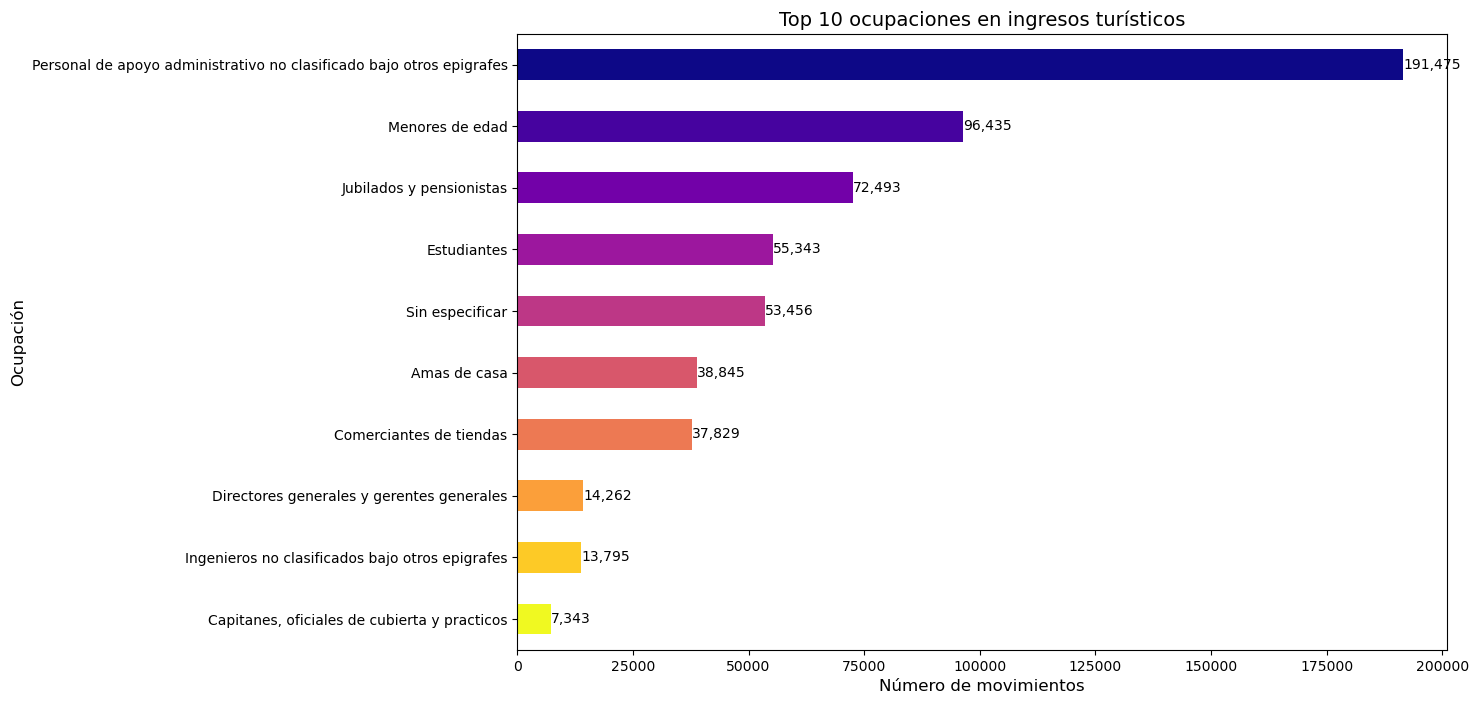

In [111]:
freq_ocup_ing = df_turismo_ing['ocu_migr'].value_counts().head(10)

top_ocup_ing = freq_ocup_ing.plot(kind='barh', figsize=(12, 8), color=plt.get_cmap('plasma')
                                  (np.linspace(0, 1, len(freq_ocup_ing))))

plt.title('Top 10 ocupaciones en ingresos turísticos', fontsize=14)
plt.xlabel('Número de movimientos', fontsize=12)
plt.ylabel('Ocupación', fontsize=12)
plt.gca().invert_yaxis()

for i, v in enumerate(freq_ocup_ing):
    top_ocup_ing.text(v + 3, i, f'{int(v):,}', va='center', fontsize=10)

plt.show()

Las profesiones u ocupaciones más populares en cuanto salidas turisticas son Personal de apoyo administrativo, menores de edad y estudiantes. Mientras que para las entradas turisticas es personal de apoyo administrativo, menores de edad y jubilados.

# CONCLUSIONES
Se ha realizado un EDA del dataset elegido según el enfoque establecido. Para ello se logró descargar la base de datos desde el repositorio del recurso en el portal del INEC. Posteriormente se lo descomprimió en la carpeta de trabajo y se procedió a cargarlo en el entorno en un objeto determinado. Con ello se partió para el análsis exploratorio. En ese sentido, se comenzó por realizar una revisión de las variables con valores nulos (NAs), se encontro que 'cla_migr' (clase de migración) es la única que tiene valores perdidos, sin embargo, debido a que eran demasiados, cernanos al 10% del dataset se decidió por no eliminarlos sino que no se consideró esa variable. Por otro lado, se encontró que de las 25 variables 4 eran numéricas, sin embargo, solamente una 'edad' podía ser realmente tratada como tal, las demás correspondian al ID, día y año, que no son realmente cuantitativas. De la variable edad se puedo evaluar que mantenia una proporción relativamente baja de outliers lo que sinifica que no es realmente necesario eliminarlos, además dichos valores atípicos paren guardar concordancia con lo que representan la edad de los registros, no eran errores como tal.

Por otro lado en cuanto a los resultados propuestos se encontró que el mes que más movimientos migratorios tiene era agosto. Las salidas se incrementan durante ese mes en mayor proporción que las entradas, esta es la tendencia para la mayoría de meses a excepción de noviembre y diciembre cuando los ingresos migratorios superan a las salidas, esto se asume se debe a que las personas que provienen principalmente del hemisferio norte donde se desarrolla el invierno con climas complicados prefieren viajar a lugares cálidos como Ecuador para pasar la temporada, además, la sociedad ecuatoriana en esas fechas suele mantenerse cercana, las familias se juntan, y la migración puede ralentizarse un poco.

En cuanto a los puntos migratorios que más movimiento registran estan dos de vía aérea y dos de vía terrestre. En ese sentido el aeropuerto de Quito concentra la mayor cantidad de movimientos en el periodo de estudio, seguido por el aeropuerto de Guayaquil, siendo ambos la puerta de entrada y salida para la migración, son el puente de conexión entre Ecuador y el mundo. Por otro lado, les siguen dos puntos terrestres, el primero en Huaquillas que conecta con Perú y el segundo en Rumichaca que une al país con Colombia.

Seguido a ello se encuentra que el 89.55% de las salidas del país se realizan por motivos de turismo y residencia. Es decir que las personas viajan para pasar vacaciones y/o porque residen fuera del país. Esto es contrastado con lo que sucede con los ingresos que a pesar de que se realizan por los mismos motivos su orden es inverso, residencia y luego turismo. Ambos engloban un 91.02% de todos los movimientos de ingreso migratorio lo que significa un total de 2.7 millones de entradas solamente en el 2024.

Finalmente, tras el análisis de las variables más relevantes se ha definido el siguiente grupo como las que permiten definir el perfil de los migrantes que ingresan y salen del país por el motivo de 'turismo'; sexo, edad, destinos y orígenes y ocupación de las personas que ingresan o salen del país, por lo tanto, los perfiles encontrados son:
* **Salidas turísticas:** El perfil de la persona que sale del Ecuador para realizar turismo es una mujer de mediana edad, alrededor de 38 años que en el mercado laboral se desempeña como personal administrativo de apoyo y se dirige a Estados Unidos, Colombia o Perú.
* **Entradas turísticas:** El perfil de la persona que ingresa a Ecuador a realizar turismo es igualmente una mujer ligeramente mayor, 39 años, que de igual forma se desempeña como personal de apoyo administrativo no categorizado, quien puede provenir con mayores probabilidades de Estados Unidos, Colombia o Perú. En el caso de los ingresos turísticos se resalta que la tercera ocupación más frecuente son jubilados y pensionistas que eligen a Ecuador como su destino para vacacionar.




In [ ]:
**LINK AL REPOSITORIO**

